# Predicting Student Test Scores (Kaggle PS S6E1) — EDA

**Task:** regression — predict the continuous `exam_score` (range ~19.6–100) from 11 features
(4 numeric, 7 low-cardinality categorical). **Metric: RMSE** (lower is better); the naive floor is
predicting the mean (RMSE = target std ≈ 18.9).

This notebook answers: **target distribution · numeric & categorical distributions · feature↔target
signal (correlations, per-category means, mutual information, single-feature baseline RMSE) ·
duplicates · train/test drift**. Figures → `reports/figures/`; written conclusions →
`reports/EDA_FINDINGS.md`.

In [1]:
%matplotlib inline
import pathlib, sys
_root = pathlib.Path.cwd()
if not (_root / "data").exists():   # notebook runs from notebooks/
    _root = _root.parent
sys.path.insert(0, str(_root))      # make `src` importable regardless of cwd

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

sns.set_theme(style="whitegrid")
RAW = _root / "data" / "raw"
FIG = _root / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

TARGET = "exam_score"
NUMERIC = ["age", "study_hours", "class_attendance", "sleep_hours"]
CATEGORICAL = ["gender", "course", "internet_access", "sleep_quality",
               "study_method", "facility_rating", "exam_difficulty"]

train = pd.read_csv(RAW / "train.csv")
test = pd.read_csv(RAW / "test.csv")
print("train", train.shape, " test", test.shape)
print("missing cells — train:", int(train.isna().sum().sum()), " test:", int(test.isna().sum().sum()))
print("duplicate feature rows in train:",
      int(train.drop(columns=['id', TARGET]).duplicated().sum()))
train.head()

train (630000, 13)  test (270000, 12)
missing cells — train: 0  test: 0
duplicate feature rows in train: 0


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


## Target distribution

count    630000.000000
mean         62.506672
std          18.916884
min          19.599000
25%          48.800000
50%          62.600000
75%          76.300000
max         100.000000
Name: exam_score, dtype: float64
skew=-0.048  kurtosis=-0.619  naive-mean RMSE (=std) = 18.9169


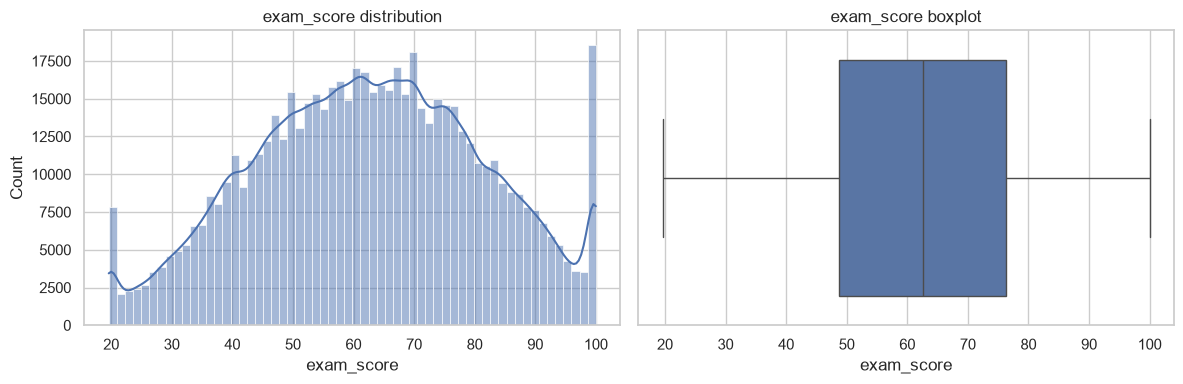

In [2]:
s = train[TARGET]
print(s.describe())
print(f"skew={s.skew():.3f}  kurtosis={s.kurt():.3f}  naive-mean RMSE (=std) = {s.std():.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(s, bins=60, kde=True, ax=ax[0]); ax[0].set_title("exam_score distribution")
sns.boxplot(x=s, ax=ax[1]); ax[1].set_title("exam_score boxplot")
fig.tight_layout(); fig.savefig(FIG / "target_distribution.png", dpi=110); plt.show()

## Numeric feature distributions

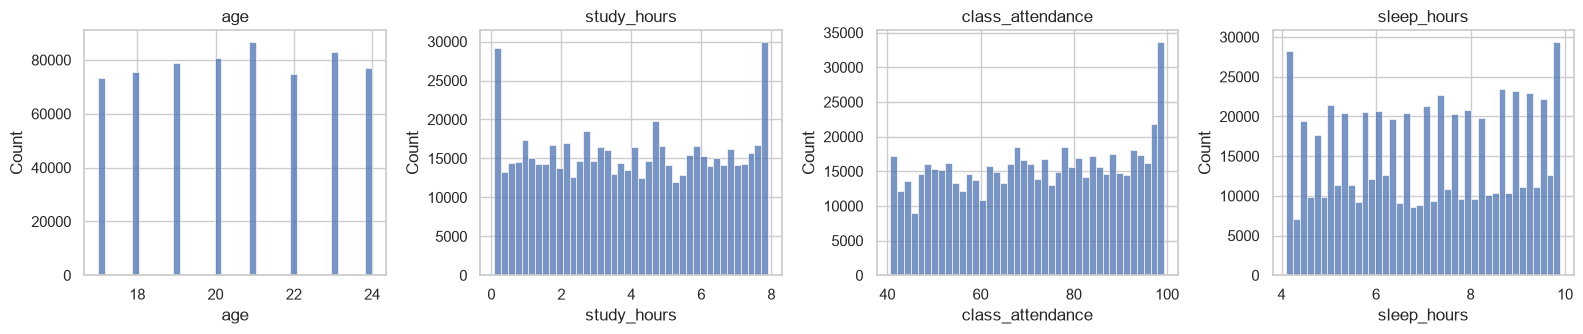

              age  study_hours  class_attendance  sleep_hours
count  630000.000   630000.000        630000.000   630000.000
mean       20.546        4.002            71.987        7.073
std         2.260        2.360            17.430        1.745
min        17.000        0.080            40.600        4.100
25%        19.000        1.970            57.000        5.600
50%        21.000        4.000            72.600        7.100
75%        23.000        6.050            87.200        8.600
max        24.000        7.910            99.400        9.900


In [3]:
fig, axes = plt.subplots(1, len(NUMERIC), figsize=(4 * len(NUMERIC), 3.5))
for ax, c in zip(axes, NUMERIC):
    sns.histplot(train[c], bins=40, ax=ax); ax.set_title(c)
fig.tight_layout(); fig.savefig(FIG / "numeric_distributions.png", dpi=110); plt.show()
print(train[NUMERIC].describe().round(3))

## Numeric ↔ target correlation

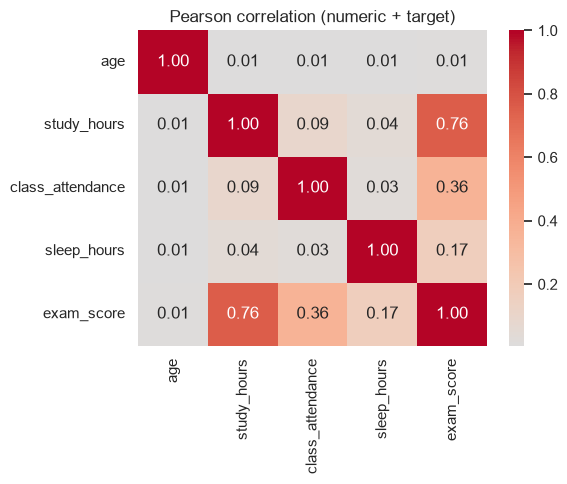

Pearson r with exam_score:
study_hours         0.7623
class_attendance    0.3610
sleep_hours         0.1674
age                 0.0105
Name: exam_score, dtype: float64


In [4]:
corr = train[NUMERIC + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Pearson correlation (numeric + target)")
fig.tight_layout(); fig.savefig(FIG / "numeric_correlation.png", dpi=110); plt.show()
print("Pearson r with exam_score:")
print(corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False).round(4))

## Categorical group-means of exam_score

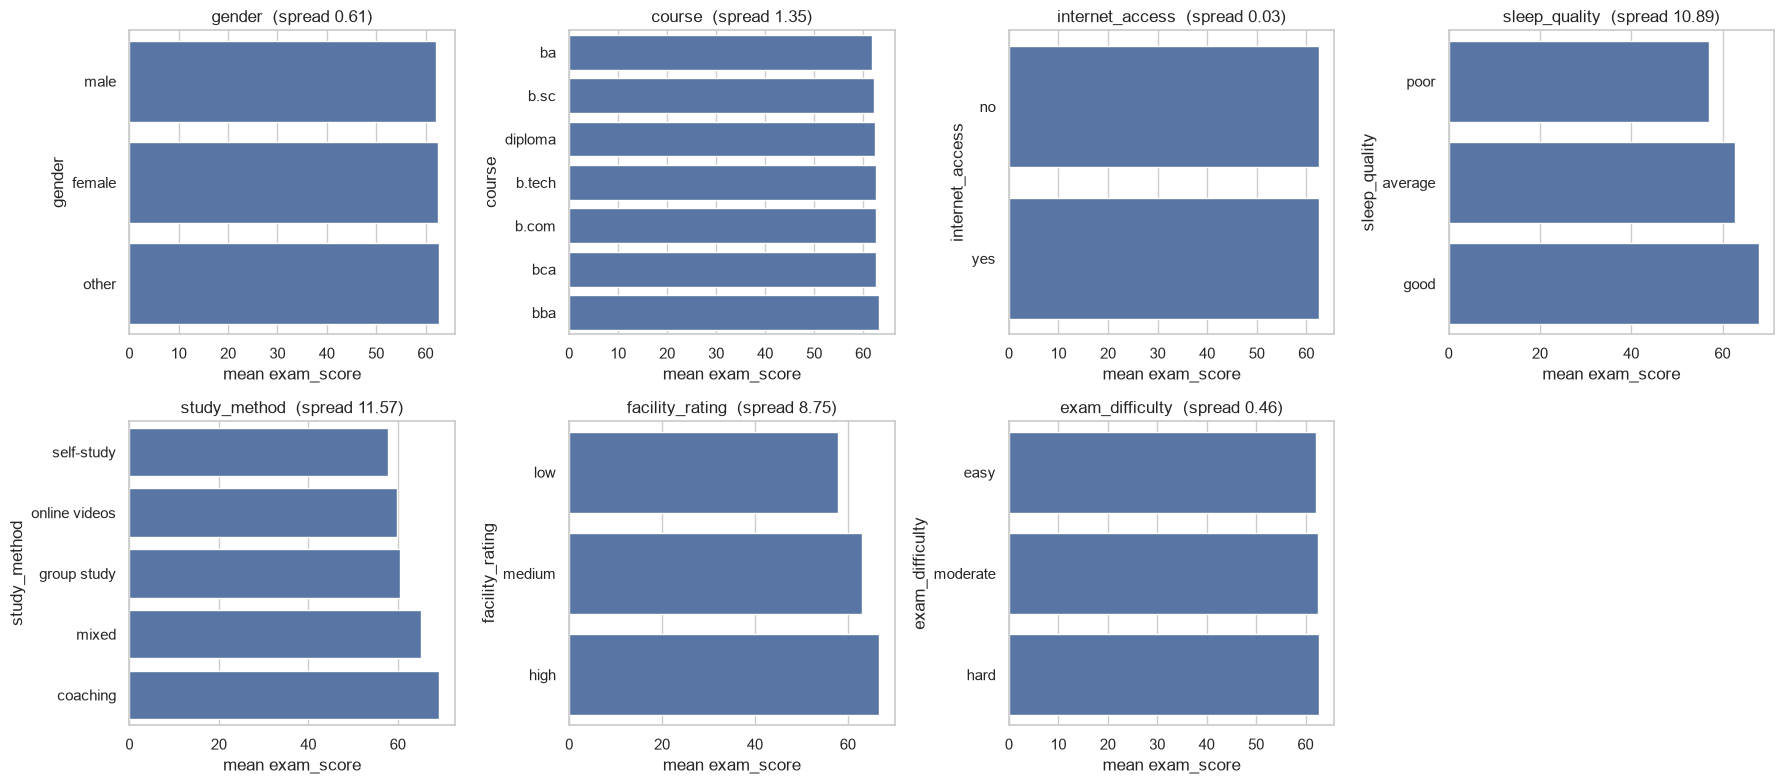

mean-exam_score spread by categorical (max level - min level):
  study_method       11.567
  sleep_quality      10.889
  facility_rating    8.753
  course             1.345
  gender             0.606
  exam_difficulty    0.457
  internet_access    0.031


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8)); axes = axes.ravel()
spread = {}
for ax, c in zip(axes, CATEGORICAL):
    g = train.groupby(c, observed=True)[TARGET].mean().sort_values()
    spread[c] = float(g.max() - g.min())
    sns.barplot(x=g.values, y=g.index, ax=ax, orient="h")
    ax.set_title(f"{c}  (spread {spread[c]:.2f})"); ax.set_xlabel("mean exam_score")
for ax in axes[len(CATEGORICAL):]:
    ax.axis("off")
fig.tight_layout(); fig.savefig(FIG / "per_category_means.png", dpi=110); plt.show()
print("mean-exam_score spread by categorical (max level - min level):")
for c, v in sorted(spread.items(), key=lambda kv: -kv[1]):
    print(f"  {c:18s} {v:.3f}")

## Mutual information with the target

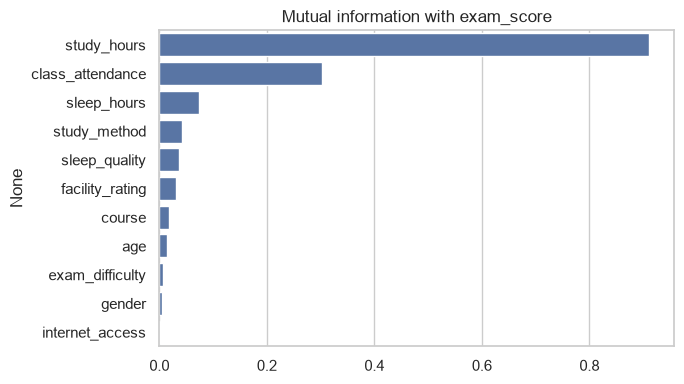

study_hours         0.9117
class_attendance    0.3019
sleep_hours         0.0731
study_method        0.0422
sleep_quality       0.0370
facility_rating     0.0306
course              0.0179
age                 0.0139
exam_difficulty     0.0070
gender              0.0045
internet_access     0.0018
dtype: float64


In [6]:
X = train[NUMERIC + CATEGORICAL].copy()
cat_idx = [X.columns.get_loc(c) for c in CATEGORICAL]
for c in CATEGORICAL:
    X[c] = X[c].astype("category").cat.codes
mi = mutual_info_regression(X, train[TARGET], discrete_features=cat_idx, random_state=42)
mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=mi.values, y=mi.index, ax=ax); ax.set_title("Mutual information with exam_score")
fig.tight_layout(); fig.savefig(FIG / "mutual_information.png", dpi=110); plt.show()
print(mi.round(4))

## Single-feature baseline RMSE (signal strength)

In [7]:
# For each feature, predict the mean exam_score within bins (10 quantile bins for numeric,
# each level for categorical) — an out-of-model measure of how much each feature alone explains.
from src.metric import rmse
mean_pred = np.full(len(train), train[TARGET].mean())
print(f"predict-global-mean RMSE = {rmse(train[TARGET], mean_pred):.4f}")
rows = []
for c in NUMERIC:
    b = pd.qcut(train[c], 10, duplicates="drop")
    pred = train.groupby(b, observed=True)[TARGET].transform("mean")
    rows.append((c, rmse(train[TARGET], pred)))
for c in CATEGORICAL:
    pred = train.groupby(c, observed=True)[TARGET].transform("mean")
    rows.append((c, rmse(train[TARGET], pred)))
sf = pd.DataFrame(rows, columns=["feature", "binned_mean_RMSE"]).sort_values("binned_mean_RMSE")
print(sf.to_string(index=False))

predict-global-mean RMSE = 18.9169


         feature  binned_mean_RMSE
     study_hours         12.296804
class_attendance         17.644385
   sleep_quality         18.378111
    study_method         18.437056
 facility_rating         18.576043
     sleep_hours         18.647782
             age         18.912330
          course         18.913941
          gender         18.915205
 exam_difficulty         18.915976
 internet_access         18.916867


## Train/test drift

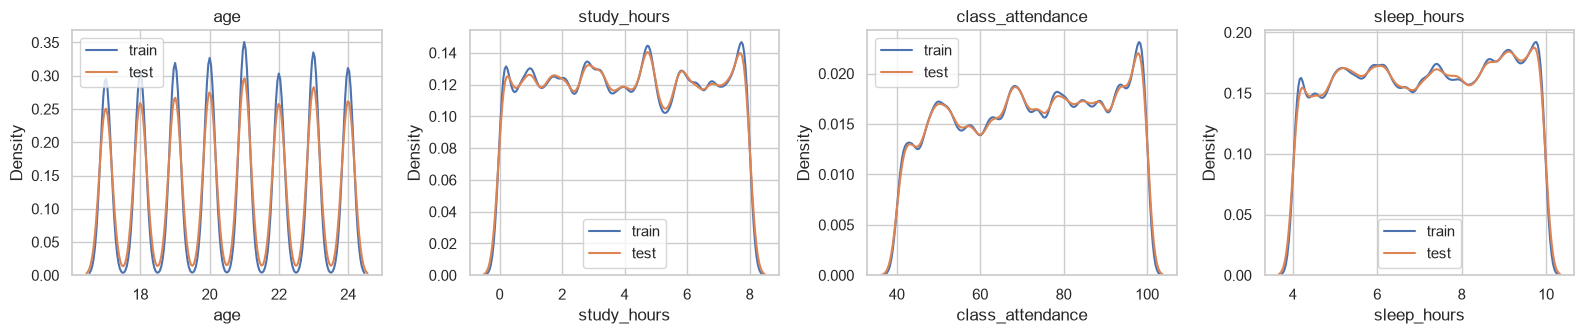

numeric mean train vs test:
                   train    test
age               20.546  20.544
study_hours        4.002   4.004
class_attendance  71.987  71.983
sleep_hours        7.073   7.072
  gender: max |train-test| level share diff = 0.0016
  course: max |train-test| level share diff = 0.0012
  internet_access: max |train-test| level share diff = 0.0013
  sleep_quality: max |train-test| level share diff = 0.0020
  study_method: max |train-test| level share diff = 0.0010
  facility_rating: max |train-test| level share diff = 0.0014
  exam_difficulty: max |train-test| level share diff = 0.0003


In [8]:
fig, axes = plt.subplots(1, len(NUMERIC), figsize=(4 * len(NUMERIC), 3.5))
for ax, c in zip(axes, NUMERIC):
    sns.kdeplot(train[c], ax=ax, label="train"); sns.kdeplot(test[c], ax=ax, label="test")
    ax.set_title(c); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "train_test_drift.png", dpi=110); plt.show()
print("numeric mean train vs test:")
print(pd.DataFrame({"train": train[NUMERIC].mean(), "test": test[NUMERIC].mean()}).round(3))
for c in CATEGORICAL:
    tr = train[c].value_counts(normalize=True)
    te = test[c].value_counts(normalize=True)
    print(f"  {c}: max |train-test| level share diff = {(tr - te).abs().max():.4f}")